In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 데이터 로딩
df = pd.read_parquet('../data/train/1_회원정보_train.parquet')
df

,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,...,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,2,40대,D,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,1,30대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,1,30대,C,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,2,40대,D,1,1,0,1,2,...,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,2,40대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,2,70대이상,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,노년생활,39
2399996,201812,TRAIN_399996,2,50대,D,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),24
2399997,201812,TRAIN_399997,1,30대,C,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,18
2399998,201812,TRAIN_399998,1,40대,E,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),27


### 각 등급별 연체금액 보유여부

In [18]:
# 1. 데이터 로딩
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=['ID', '기준년월', '이용금액_연체_B0M'])

# 2. 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')

# 3. 연체금액 유무 이진 변수 생성
df['연체금액_보유여부'] = (df['이용금액_연체_B0M'] > 0).astype(int)

# 4. Segment별 연체 유무 통계 요약
summary = df.groupby(['Segment', '연체금액_보유여부'])['ID'].count().unstack(fill_value=0)
summary.columns = ['연체 없음', '연체 있음']
summary['총합'] = summary.sum(axis=1)
summary['연체 비율(%)'] = (summary['연체 있음'] / summary['총합'] * 100).round(2)

# 5. 결과 출력
display(summary)

,연체 없음,연체 있음,총합,연체 비율(%)
Segment,,,,
A,955,17,972,1.75
B,138,6,144,4.17
C,123560,4030,127590,3.16
D,337280,11962,349242,3.43
E,1883192,38860,1922052,2.02


In [43]:
# B등급 & 연체금액 있음인 고객만 필터링
b_with_debt = df[(df['Segment'] == 'B') & (df['연체금액_보유여부'] == 1)]

# 결과 출력
result = b_with_debt[['ID', 'Segment', '기준년월', '이용금액_연체_B0M']]
result

,ID,Segment,기준년월,이용금액_연체_B0M
256790,TRAIN_256790,B,201807,3103
656790,TRAIN_256790,B,201808,2866
1056790,TRAIN_256790,B,201809,2826
1456790,TRAIN_256790,B,201810,3005
1856790,TRAIN_256790,B,201811,2744
2256790,TRAIN_256790,B,201812,2574


- B 등급의 동일 고객이 6개월동안 연체한 이력 때문에 B 등급의 `이용금액_연체_B0M` 평균이 치솟은 거였다.

### 1. B 등급의 평균이 월등히 높았던 `선입금원금_B0M` 그래프에 대한 분석

In [ ]:
# 필요한 컬럼만 로드
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=['ID', '기준년월', '선입금원금_B0M'])

# 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')

b_advance = df[(df['Segment'] == 'B') & (df['선입금원금_B0M'] > 0)]

In [50]:
# ID별 합계 확인
id_summary = b_advance.groupby('ID')['선입금원금_B0M'].sum().sort_values(ascending=False)

# 전체 목록 보기 (필요시 일부 출력)
display(b_advance[['ID', 'Segment','기준년월', '선입금원금_B0M']])
print("\nID별 선입금 합계:\n", id_summary)

,ID,Segment,기준년월,선입금원금_B0M
61321,TRAIN_061321,B,201807,7377
61664,TRAIN_061664,B,201807,10707
103311,TRAIN_103311,B,201807,13396
112900,TRAIN_112900,B,201807,13401
158775,TRAIN_158775,B,201807,9092
...,...,...,...,...
2294250,TRAIN_294250,B,201812,9516
2305269,TRAIN_305269,B,201812,7309
2362774,TRAIN_362774,B,201812,12101
2368113,TRAIN_368113,B,201812,11589



ID별 선입금 합계:
 ID
TRAIN_112900    97622
TRAIN_103311    89139
TRAIN_362774    82745
TRAIN_061664    73810
TRAIN_368113    73774
TRAIN_289152    59779
TRAIN_194417    57820
TRAIN_158775    52961
TRAIN_294250    50498
TRAIN_390620    33044
TRAIN_061321    12886
TRAIN_305269     7309
Name: 선입금원금_B0M, dtype: int64


- `선입금원금_B0M`은 특정 고객 한 명이 만든 왜곡은 아니고, 다수의 고액 선입금 고객에 의해 평균이 상승한 것으로 보임.

### 2. `선입금원금_B0M` KDE 분포

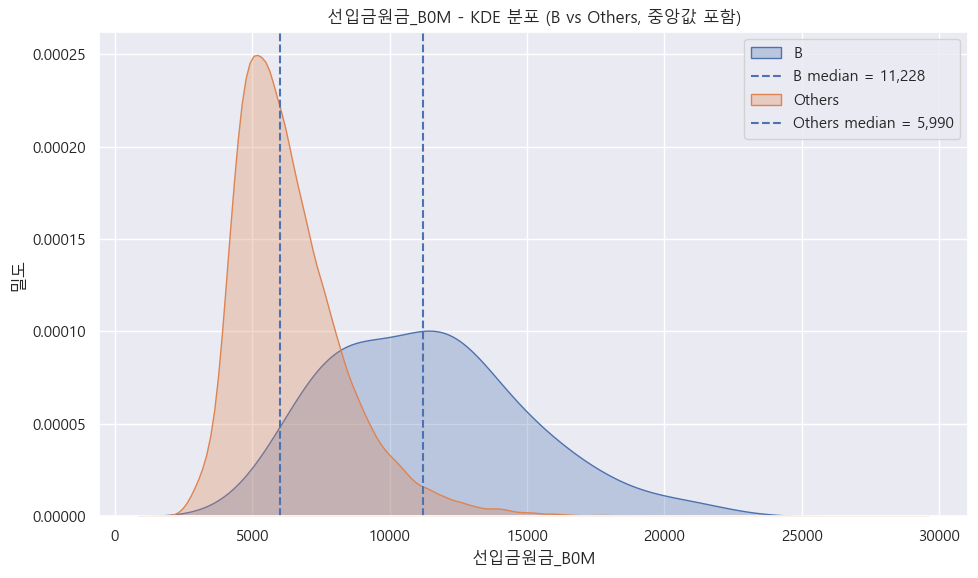

In [51]:
# B / 비B 구분
df['Segment_B_vs_Others'] = df['Segment'].apply(lambda x: 'B' if x == 'B' else 'Others')

# 시각화 대상 컬럼
target_col = '선입금원금_B0M'

# 결측 제거 및 값 존재하는 샘플만 사용
filtered = df[df[target_col].notna() & (df[target_col] > 0)].copy()

# KDE 시각화
plt.figure(figsize=(10, 6))
for label in ['B', 'Others']:
    data = filtered[filtered['Segment_B_vs_Others'] == label][target_col]
    sns.kdeplot(data, label=label, fill=True, alpha=0.3)

    # 중앙값 선 추가
    median = data.median()
    plt.axvline(median, linestyle='--', linewidth=1.5, label=f'{label} median = {int(median):,}')

# 제목 및 라벨
plt.title(f'{target_col} - KDE 분포 (B vs Others, 중앙값 포함)')
plt.xlabel(target_col)
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.show()

#### 1. 중앙값 차이
- B 등급 고객의 중앙값: 약 11,228
- 그 외 등급의 중앙값: 약 5,990

B 등급의 중앙값이 거의 2배 수준이며, 이는 단순 평균이 아닌 분포 중심 자체가 다른 것을 시사한다.

#### 2. 분포 폭
- B 등급 고객: 더 넓게 퍼져 있고 오른쪽으로 긴 꼬리를 가짐 (positive skew)
- Other 등급 고객: 더 뾰족하고 좌우로 좁은 분포

B 등급 고객 내에서도 일부 고액 선입금 고객이 존재함을 암시한다. (특히 앞서 확인한 TRAIN_112900 같은 고객)

#### 3. 모델링 측면에서 시사점
- B 등급을 잘 설명하는 변수 후보로 선입금원금_B0M이 충분히 가치 있어 보인다.
- 다만, 극단치의 영향력이 큼으로 log 변환이나 winsorizing 등 추가 처리가 필요할 수도 있다.

### 3. B vs Other KDE + 중앙값 비교

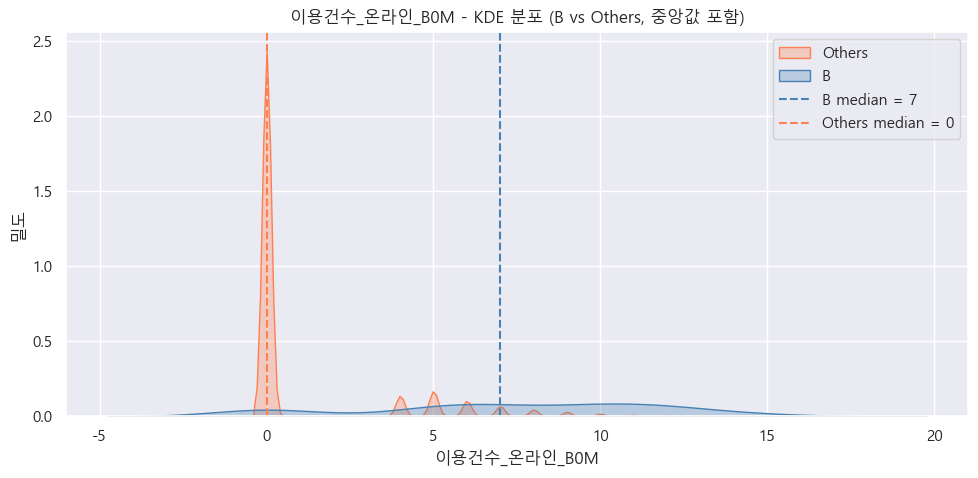

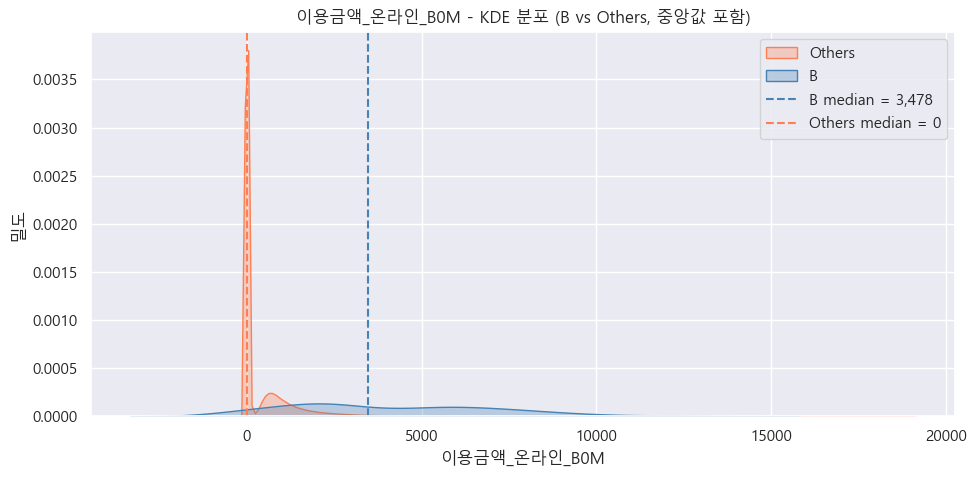

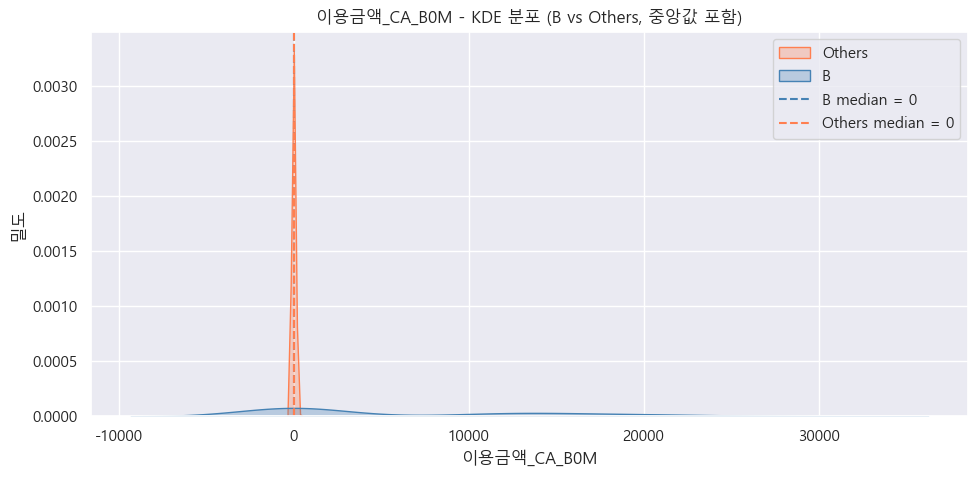

In [57]:
# 3번에서 불러올 컬럼
cols = ['ID', '기준년월', '이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M']

# 데이터 불러오기
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=cols)

# 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')

# KDE + 중앙값 시각화 함수 정의
def kde_with_median(df, col):
    df_b = df[df['Segment'] == 'B'][col].dropna()
    df_others = df[df['Segment'] != 'B'][col].dropna()

    if len(df_b) == 0 or len(df_others) == 0:
        print(f"데이터 부족: {col}")
        return

    median_b = int(df_b.median())
    median_others = int(df_others.median())

    plt.figure(figsize=(10, 5))
    sns.kdeplot(df_others, label='Others', fill=True, alpha=0.3, color='coral')
    sns.kdeplot(df_b, label='B', fill=True, alpha=0.3, color='steelblue')

    plt.axvline(median_b, linestyle='--', color='steelblue', label=f"B median = {median_b:,}")
    plt.axvline(median_others, linestyle='--', color='coral', label=f"Others median = {median_others:,}")

    plt.title(f"{col} - KDE 분포 (B vs Others, 중앙값 포함)")
    plt.xlabel(col)
    plt.ylabel("밀도")
    plt.legend()
    plt.tight_layout()
    plt.show()

cols_list = ['이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M']

# 컬럼별 시각화
for col in cols_list:
    if col not in df.columns:
        print(f"컬럼 없음: {col}")
        continue
    kde_with_median(df, col)

In [58]:
# 필요한 컬럼만 로드
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=['ID', '기준년월', '이용금액_CA_B0M'])

# 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')

# B등급 + CA 이용금액 > 0인 고객만 추출
b_ca = df[(df['Segment'] == 'B') & (df['이용금액_CA_B0M'] > 0)]

# ID별 CA 이용금액 합계 정렬
id_summary = b_ca.groupby('ID')['이용금액_CA_B0M'].sum().sort_values(ascending=False)

# 상세 목록 출력
display(b_ca[['ID', 'Segment', '기준년월', '이용금액_CA_B0M']])
print("\nID별 CA 이용금액 합계:\n", id_summary)

,ID,Segment,기준년월,이용금액_CA_B0M
33783,TRAIN_033783,B,201807,26649
61321,TRAIN_061321,B,201807,21709
61664,TRAIN_061664,B,201807,16285
103311,TRAIN_103311,B,201807,17590
235877,TRAIN_235877,B,201807,10224
294250,TRAIN_294250,B,201807,13892
305269,TRAIN_305269,B,201807,10962
362774,TRAIN_362774,B,201807,11266
368113,TRAIN_368113,B,201807,19243
390620,TRAIN_390620,B,201807,18562



ID별 CA 이용금액 합계:
 ID
TRAIN_033783    144448
TRAIN_061321    125403
TRAIN_368113    119619
TRAIN_390620     95349
TRAIN_103311     93370
TRAIN_061664     89739
TRAIN_294250     75166
TRAIN_305269     73479
TRAIN_362774     68404
TRAIN_112900     46042
TRAIN_235877     10224
Name: 이용금액_CA_B0M, dtype: int64


### 4. A vs B

In [2]:
# 3번에서 불러올 컬럼
cols = ['ID', '기준년월', '이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M']

# 데이터 불러오기
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=cols)

# 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')

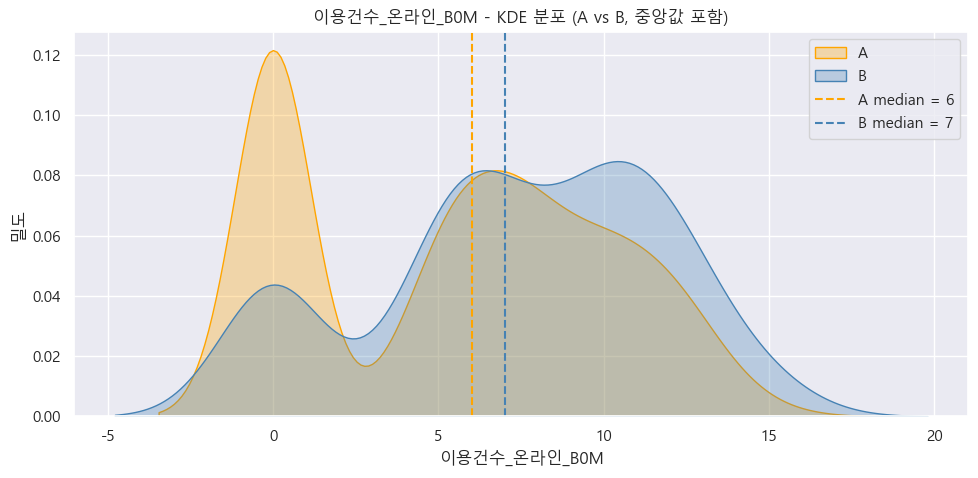

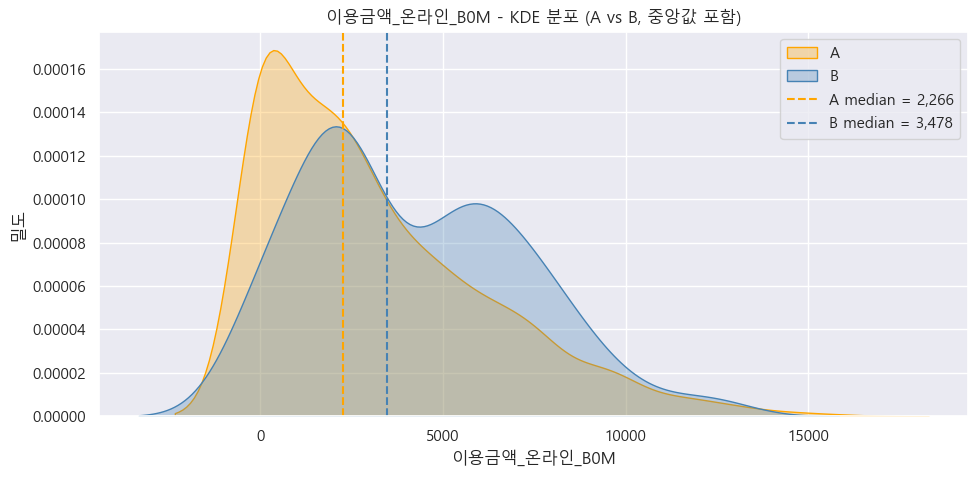

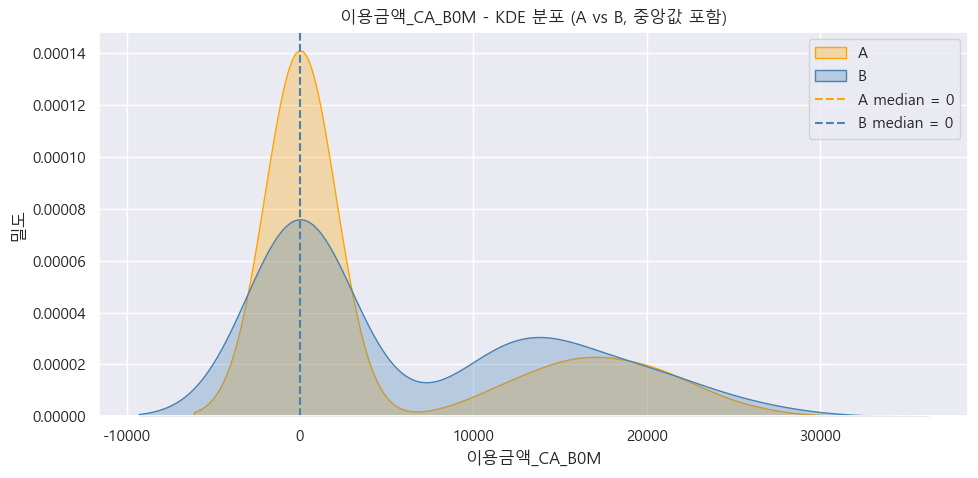

In [3]:
# A vs B 전용 KDE 함수
def kde_ab(df, col):
    df_a = df[df['Segment'] == 'A'][col].dropna()
    df_b = df[df['Segment'] == 'B'][col].dropna()

    if len(df_a) == 0 or len(df_b) == 0:
        print(f"데이터 부족: {col}")
        return

    median_a = int(df_a.median())
    median_b = int(df_b.median())

    plt.figure(figsize=(10, 5))
    sns.kdeplot(df_a, label='A', fill=True, alpha=0.3, color='orange')
    sns.kdeplot(df_b, label='B', fill=True, alpha=0.3, color='steelblue')

    plt.axvline(median_a, linestyle='--', color='orange', label=f"A median = {median_a:,}")
    plt.axvline(median_b, linestyle='--', color='steelblue', label=f"B median = {median_b:,}")

    plt.title(f"{col} - KDE 분포 (A vs B, 중앙값 포함)")
    plt.xlabel(col)
    plt.ylabel("밀도")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 시각화 대상 컬럼
cols_list = ['이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M']

# 실행
for col in cols_list:
    if col in df.columns:
        kde_ab(df, col)
    else:
        print(f"컬럼 없음: {col}")


1. 분포 겹침이 심하다.
    - `이용건수_온라인_B0M`: A와 B의 분포가 많이 겹치고 중앙값도 A:6, B:7로 차이가 나지 않음
    - `이용금액_온라인_B0M`: B가 약간 더 높긴 하지만, 전반적으로 오버랩이 너무 크다.
    - `이용금액_CA_B0M`: 두 집단 모두 중앙값이 0이며, 극단값이 돈재하지만 분포는 대체로 겹친다.

2. 단일 피처가 아닌 복합 피처 설계가 필요
    - `이용금액_온라인_B0M` / `이용건수_온라인_B0M` → 온라인 건당 금액
    - `이용금액_온라인_B0M` / `이용금액_CA_B0M` → 온라인 대비 CA 비중
    - `선입금원금_B0M` / `이용금액_온라인_B0M` → 선입금 활용 비율

In [9]:
# 3번에서 불러올 컬럼
cols = ['ID', '기준년월', '이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M', '선입금원금_B0M']

# 데이터 불러오기
df_1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df_3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=cols)

# 병합
df_1_3 = df_1.merge(df_3, on=['ID', '기준년월'], how='left')

In [10]:
# 0: 선입금 안 한 경우, 1: 선입금 한 경우
df_1_3['선입금_여부'] = (df_1_3['선입금원금_B0M'] > 0).astype(int)

In [16]:
df_1_3.groupby('Segment')['선입금_여부'].value_counts().unstack(fill_value=0)

선입금_여부,0,1
Segment,,
A,882,90
B,83,61
C,111051,16539
D,311325,37917
E,1847778,74274


In [17]:
df_1_3.groupby('Segment')['선입금_여부'].mean().round(4) * 100

Segment
A     9.26
B    42.36
C    12.96
D    10.86
E     3.86
Name: 선입금_여부, dtype: float64

In [ ]:
# print(df_1_3.groupby('Segment')['선입금_여부'].value_counts().unstack(fill_value=0))
# print(df_1_3.groupby('Segment')['선입금_여부'].mean().round(4) * 100)

선입금_여부         0      1
Segment                
A            882     90
B             83     61
C         111051  16539
D         311325  37917
E        1847778  74274
Segment
A     9.26
B    42.36
C    12.96
D    10.86
E     3.86
Name: 선입금_여부, dtype: float64


In [22]:
# 필요한 컬럼만 추출
save_cols = ['Segment', '선입금_여부']
df_deposit = df_1_3[save_cols].copy()

# 저장 경로
# df_deposit.to_parquet('../features/3_승인매출정보/feature_선입금_여부.parquet', index=False)
df_deposit.to_csv('../features/3_승인매출정보/feature_선입금_여부.csv', index=False)

In [23]:
df_deposit

,Segment,선입금_여부
0,D,0
1,E,0
2,C,0
3,D,0
4,E,0
...,...,...
2399995,E,0
2399996,D,0
2399997,C,0
2399998,E,0


#### 선입금 고객 한정

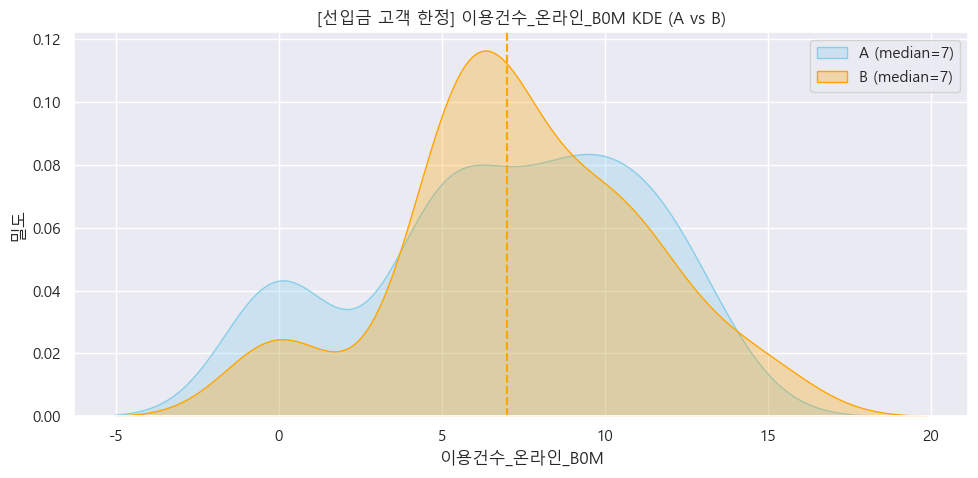

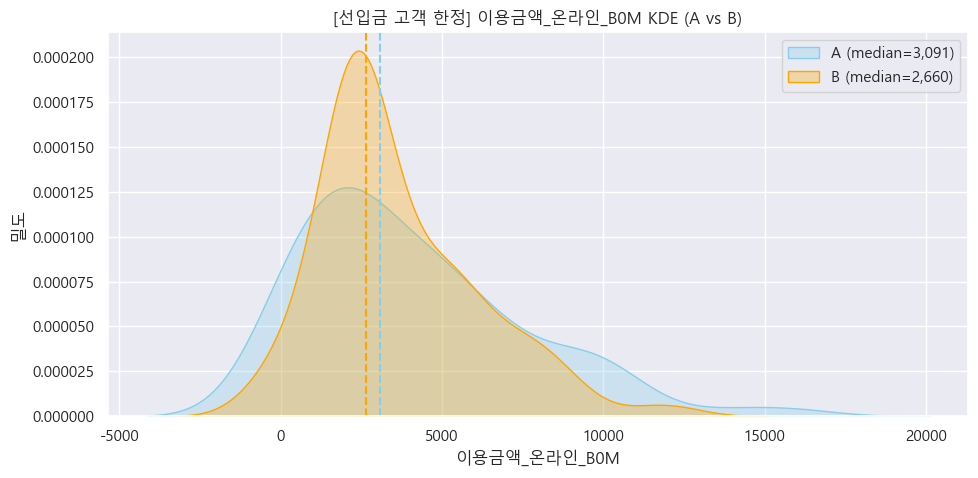

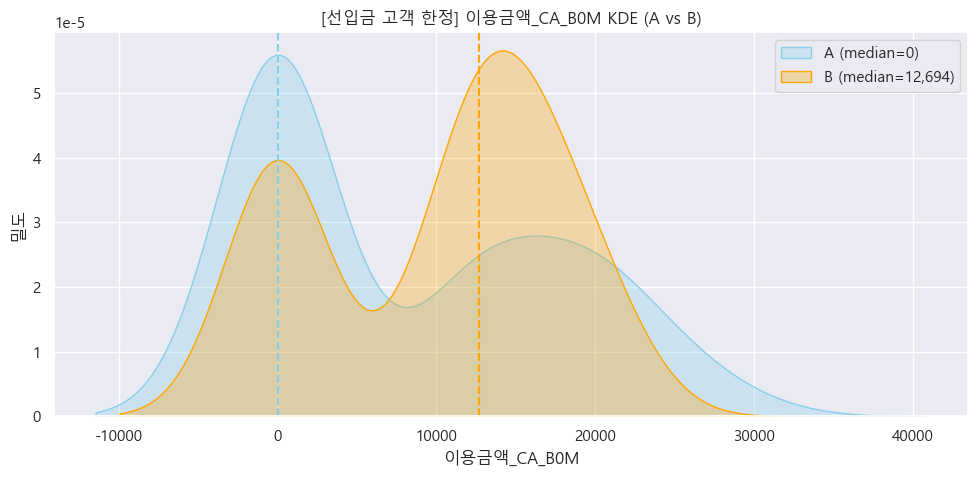

In [ ]:
# 1. 데이터 불러오기
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet',
                      columns=['ID', '기준년월', '선입금원금_B0M', '이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M'])

# 2. 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')
df['선입금_여부'] = (df['선입금원금_B0M'] > 0).astype(int)

# 3. A/B 고객 중 선입금 경험 있는 고객만 추출
ab_paid = df[(df['Segment'].isin(['A', 'B'])) & (df['선입금_여부'] == 1)].copy()
ab_paid['target'] = (ab_paid['Segment'] == 'A').astype(int)

# 4. 비교할 컬럼 목록
cols = ['이용건수_온라인_B0M', '이용금액_온라인_B0M', '이용금액_CA_B0M']

# 5. KDE + 중앙값 시각화

def kde_ab_paid(df, col):
    data_a = df[df['Segment'] == 'A'][col].dropna()
    data_b = df[df['Segment'] == 'B'][col].dropna()

    median_a = int(data_a.median())
    median_b = int(data_b.median())

    plt.figure(figsize=(10, 5))
    sns.kdeplot(data_a, label=f"A (median={median_a:,})", fill=True, alpha=0.3, color='skyblue')
    sns.kdeplot(data_b, label=f"B (median={median_b:,})", fill=True, alpha=0.3, color='orange')
    plt.axvline(median_a, linestyle='--', color='skyblue')
    plt.axvline(median_b, linestyle='--', color='orange')
    plt.title(f"[선입금 고객 한정] {col} KDE (A vs B)")
    plt.xlabel(col)
    plt.ylabel("밀도")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 6. 시각화 실행
for col in cols:
    kde_ab_paid(ab_paid, col)

[선입금 고객 한정] 이용금액_CA_B0M
- 선입금 + CA 활용도가 높은 B 고객이라는 특징은 꽤 명확해보임.

#### 파생피처 2

1. `온라인_건당_금액` = `이용금액_온라인_B0M` / `이용건수_온라인_B0M`
    - 한 번 결제할 때 얼마를 쓰는가?
    - B 고객은 건수가 많고 금액도 적당히 높은 편이었으므로, 건당 금액은 A와 비슷하거나 다소 낮을 수 있음.

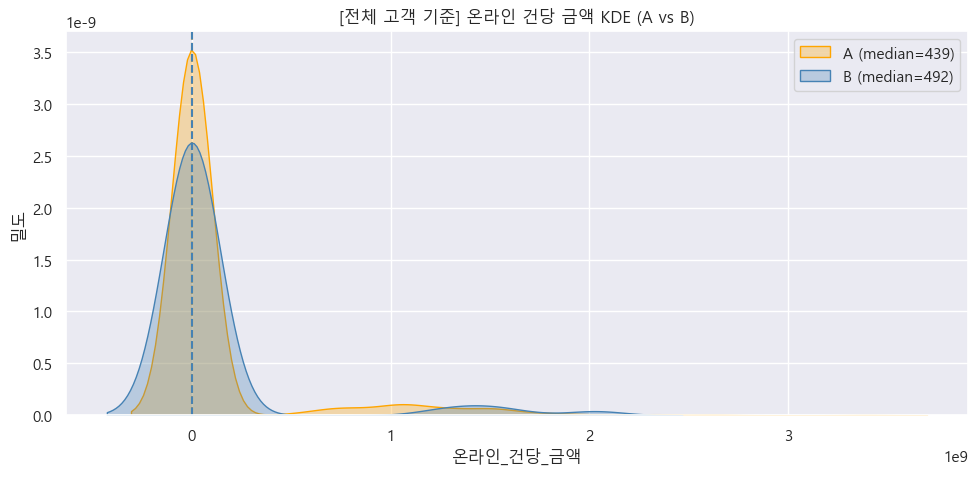

In [25]:
# 온라인 건당 금액 계산 (0건 방지 위해 1e-6 더해줌)
df['온라인_건당_금액'] = df['이용금액_온라인_B0M'] / (df['이용건수_온라인_B0M'] + 1e-6)

# A vs B 필터링
df_ab = df[df['Segment'].isin(['A', 'B'])].copy()

# 그룹별 데이터
data_a = df_ab[df_ab['Segment'] == 'A']['온라인_건당_금액'].dropna()
data_b = df_ab[df_ab['Segment'] == 'B']['온라인_건당_금액'].dropna()

# 중앙값
median_a = int(data_a.median())
median_b = int(data_b.median())

# 시각화
plt.figure(figsize=(10, 5))
sns.kdeplot(data_a, label=f'A (median={median_a:,})', fill=True, color='orange', alpha=0.3)
sns.kdeplot(data_b, label=f'B (median={median_b:,})', fill=True, color='steelblue', alpha=0.3)
plt.axvline(median_a, linestyle='--', color='orange')
plt.axvline(median_b, linestyle='--', color='steelblue')
plt.title('[전체 고객 기준] 온라인 건당 금액 KDE (A vs B)')
plt.xlabel('온라인_건당_금액')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.show()

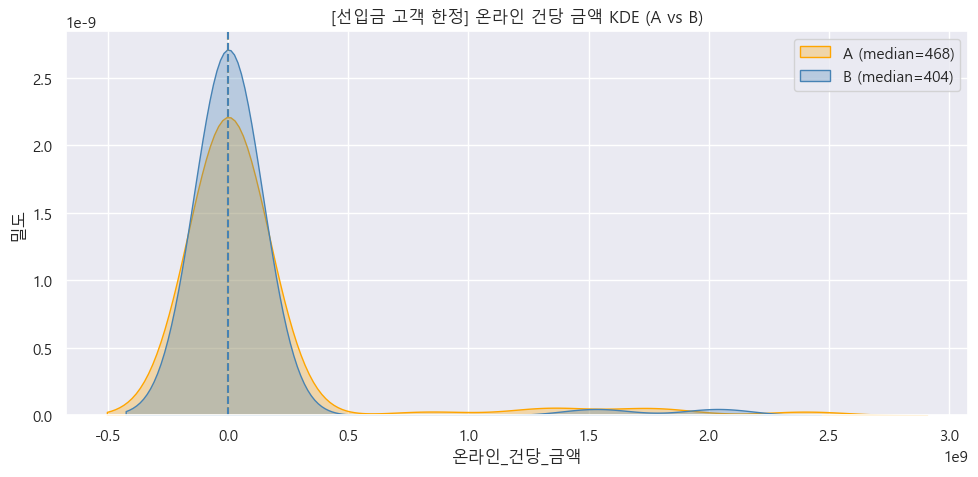

In [26]:
# 1. 데이터 로딩
df1 = pd.read_parquet('../data/train/1_회원정보_train.parquet', columns=['ID', '기준년월', 'Segment'])
df3 = pd.read_parquet('../data/train/3_승인매출정보_train.parquet', columns=['ID', '기준년월',
                                                                            '이용건수_온라인_B0M',
                                                                            '이용금액_온라인_B0M',
                                                                            '선입금원금_B0M'])

# 2. 병합
df = df1.merge(df3, on=['ID', '기준년월'], how='left')

# 3. 파생 변수 생성
df['온라인_건당_금액'] = df['이용금액_온라인_B0M'] / (df['이용건수_온라인_B0M'] + 1e-6)
df['선입금_여부'] = (df['선입금원금_B0M'] > 0).astype(int)

# 4. A/B 고객 중 선입금한 사람만 추출
df_ab = df[(df['Segment'].isin(['A', 'B'])) & (df['선입금_여부'] == 1)].copy()

# 5. 분포 계산
data_a = df_ab[df_ab['Segment'] == 'A']['온라인_건당_금액'].dropna()
data_b = df_ab[df_ab['Segment'] == 'B']['온라인_건당_금액'].dropna()

# 중앙값 계산
median_a = int(data_a.median())
median_b = int(data_b.median())

# 6. 시각화
plt.figure(figsize=(10, 5))
sns.kdeplot(data_a, label=f"A (median={median_a:,})", fill=True, alpha=0.3, color='orange')
sns.kdeplot(data_b, label=f"B (median={median_b:,})", fill=True, alpha=0.3, color='steelblue')

plt.axvline(median_a, linestyle='--', color='orange')
plt.axvline(median_b, linestyle='--', color='steelblue')
plt.title('[선입금 고객 한정] 온라인 건당 금액 KDE (A vs B)')
plt.xlabel('온라인_건당_금액')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# 건수 통계 요약
summary = df.groupby('Segment')['이용건수_온라인_B0M'].describe().round(2)
display(summary)

# 건수가 0건인 고객 수 (전체 / Segment별)
zero_count = df[df['이용건수_온라인_B0M'] == 0].groupby('Segment')['ID'].count()
total_count = df.groupby('Segment')['ID'].count()
zero_ratio = (zero_count / total_count * 100).round(2)

# 결과 통합 보기
zero_df = pd.DataFrame({
    '0건 고객 수': zero_count,
    '전체 고객 수': total_count,
    '0건 비율(%)': zero_ratio
}).fillna(0).astype({'0건 고객 수': 'int', '전체 고객 수': 'int'})

display(zero_df)

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
A,972.0,5.45,4.57,0.0,0.0,6.0,9.0,16.0
B,144.0,7.38,4.31,0.0,5.0,7.5,11.0,15.0
C,127590.0,3.61,3.90,0.0,0.0,4.0,7.0,19.0
D,349242.0,2.65,3.36,0.0,0.0,0.0,5.0,17.0
E,1922052.0,0.71,1.92,0.0,0.0,0.0,0.0,16.0


,0건 고객 수,전체 고객 수,0건 비율(%)
Segment,,,
A,342,972,35.19
B,25,144,17.36
C,62006,127590,48.60
D,201893,349242,57.81
E,1669302,1922052,86.85


In [30]:
print(zero_df)

         0건 고객 수  전체 고객 수  0건 비율(%)
Segment                            
A            342      972     35.19
B             25      144     17.36
C          62006   127590     48.60
D         201893   349242     57.81
E        1669302  1922052     86.85


In [3]:
# 1. 데이터 불러오기
df_sales = pd.read_parquet('../data/train/3_승인매출정보_train.parquet')  # B0M 컬럼 포함
df_label = pd.read_parquet('../data/train/1_회원정보_train.parquet')  # Segment 포함

# 2. 병합: ID + 기준년월 기준
df = df_sales.merge(df_label[['ID', '기준년월', 'Segment']], on=['ID', '기준년월'], how='left')

# 3. Segment 순서 지정
segment_order = ['A', 'B', 'C', 'D', 'E']
df['Segment'] = pd.Categorical(df['Segment'], categories=segment_order, ordered=True)

# 4. 기준년월 문자열 처리
df['기준년월'] = df['기준년월'].astype(str)

In [4]:
# 시각화 스타일 설정
# sns.set(style='whitegrid')

# 비교하고 싶은 컬럼들 입력
target_cols = [
    '카드이용한도금액_B1M',
    '카드이용한도금액_B2M',
    '카드이용한도금액'
]

# Segment 순서 고정
segment_order = ['A', 'B', 'C', 'D', 'E']

# 각 컬럼별 평균/중앙값 요약 + KDE plot
for col in target_cols:
    if col not in df.columns:
        continue

    print(f"\n[요약 통계] {col}")
    display(df.groupby('Segment')[col]
            .agg(['mean', 'median', 'std', 'count'])
            .reindex(segment_order))

    plt.figure(figsize=(8, 5))
    for seg in segment_order:
        data = df[df['Segment'] == seg][col].dropna()
        if len(data) > 0:
            sns.kdeplot(data, label=f'Segment {seg}', fill=True, alpha=0.3)
    
    plt.title(f'{col} - KDE 분포 (Segment별)')
    plt.xlabel(col)
    plt.ylabel('밀도')
    plt.legend()
    plt.tight_layout()
    plt.show()
